# temporal predictions 

using encoders instead of sparse embedding settling loop in predictive coding to do autoregressive prediciton/generation task. Architecture of predictive coding based model in temporal_predictive_coding meant that pixel shfits resulted in compeltely different neurons firing in the predictive coding model, therefore resulting in chaotic embeddings and minimum cosine similarity between consecutive frames was 50% which isn't very good. Also 31% of the embedding was pure noise. This meant it was an impossible task to actually have the temporalNN learn anything beacuse the embeddings were inherently chaotic. Now use encoder instead. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torch.nn.functional as F
import math
import os as os

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")

Using device: cpu
PyTorch: 2.13.0
NumPy: 2.5.2


dataset/input variables

In [4]:
if not os.path.exists("./data/MovingMNIST/mnist_test_seq.npy"):
    datasets.MovingMNIST._URL = "https://huggingface.co/datasets/goodgoodideas/STDN/resolve/main/mnist_test_seq.npy"
input_data = datasets.MovingMNIST(root="./data", split=None, download=True)

100.0%


In [5]:
def make_variables(image, initial_r_size=64, num_channels=16, num_layers=2, kernel_size=4, padding=1, stride=2):
    I = image
    if I.ndim == 4:
        previous_num_channels = I.shape[1]
    elif I.ndim == 3:
        previous_num_channels = I.shape[0]
    else:
        previous_num_channels = 1
    r = []
    encoders = []
    deconvs = []
    out_channels = num_channels * 2
    for i in range(num_layers):
        r_size = initial_r_size // (2 ** (i + 1))
        r.append(torch.randn(1, out_channels, r_size, r_size) * 0.01)
        encoder = nn.Conv2d(previous_num_channels, out_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False)
        nn.init.zeros_(encoder.weight)
        encoders.append(encoder)
        deconvs.append(nn.ConvTranspose2d(out_channels, previous_num_channels, kernel_size=kernel_size, padding=padding, stride=stride, bias=False))
        previous_num_channels = out_channels
        out_channels = out_channels * 2
    return I, r, deconvs, encoders

In [6]:
class ConvGRUCell(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        padding = kernel_size // 2
        self.conv_zr = nn.Conv2d(channels * 2, channels * 2, kernel_size, padding=padding)
        self.conv_h = nn.Conv2d(channels * 2, channels, kernel_size, padding=padding)

    def forward(self, x, h):
        if h is None:
            h = torch.zeros_like(x)
        zr = torch.sigmoid(self.conv_zr(torch.cat([x, h], dim=1)))
        z, r = zr.chunk(2, dim=1)
        h_tilde = torch.tanh(self.conv_h(torch.cat([x, r * h], dim=1)))
        return (1.0 - z) * h + z * h_tilde


class TemporalConvRNN(nn.Module):
    def __init__(self, r, delta_scale=0.1):
        super().__init__()
        self.delta_scale = delta_scale
        self.cells = nn.ModuleList()
        self.readouts = nn.ModuleList()
        for ri in r:
            ch = ri.shape[1]
            self.cells.append(ConvGRUCell(ch))
            readout = nn.Conv2d(ch, ch, kernel_size=3, padding=1)
            nn.init.zeros_(readout.weight)
            nn.init.zeros_(readout.bias)
            self.readouts.append(readout)

    def init_hidden(self, r_like):
        return [torch.zeros_like(ri) for ri in r_like]

    def forward(self, r_in, hidden=None):
        if hidden is None:
            hidden = self.init_hidden(r_in)
        r_pred, h_new, deltas = [], [], []
        for cell, readout, x, h in zip(self.cells, self.readouts, r_in, hidden):
            h_t = cell(x, h)
            delta = self.delta_scale * torch.tanh(readout(h_t))
            deltas.append(delta)
            r_pred.append(x + delta)
            h_new.append(h_t)
        return r_pred, h_new, deltas

TemporalNN = TemporalConvRNN


Training Loop

In [7]:

def encode_I(I, encoders, num_layers):
    r = [encoders[0](I)]
    for i in range(1, num_layers):
        r.append(encoders[i](r[i - 1]))
    return r

def _perturb_r(rs, noise_std):
    if noise_std is None or noise_std <= 0:
        return rs
    return [ri + torch.randn_like(ri) * noise_std for ri in rs]


def _update_temporal_params(temporal_nn, lr_u, lambda_u, max_grad_norm=1.0):
    torch.nn.utils.clip_grad_norm_(temporal_nn.parameters(), max_grad_norm)
    with torch.no_grad():
        for param in temporal_nn.parameters():
            if param.grad is not None:
                param -= lr_u * (param.grad + lambda_u * param)
                param.grad = None


def train_loop(I_curr, r_prev1, r_curr, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn, hidden=None, r_noise_std=0.0, lambda_slow=0.1, delta_loss_weight=20.0):
    I_curr = I_curr.float()
    if I_curr.ndim == 3:
        I_curr = I_curr.unsqueeze(0)
    e_spatial = [None] * num_layers
    e_temporal = [None] * num_layers
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    has_prev = r_prev1 is not None
    if r_prev1 is None:
        r_prev1 = [torch.zeros_like(ri) for ri in r_curr]
    else:
        r_prev1 = [ri.detach() for ri in r_prev1]

    if hidden is None:
        hidden = temporal_nn.init_hidden(r_curr)
    else:
        hidden = [hi.detach() for hi in hidden]

    h_new = hidden
    r_pred = None
    delta_stats = (0.0, 0.0)

    for out_epoch in range(num_epochs_outer):
        r_in = _perturb_r([ri.detach() for ri in r_prev1], r_noise_std)
        h_in = [hi.detach() for hi in hidden]
        r_pred, h_new, deltas = temporal_nn(r_in, h_in)
        r_curr = encode_I(I_curr, encoders, num_layers)


        e_spatial[0] = I_curr - f(deconvs[0](r_curr[0]))
        r_pred, h_new, deltas = temporal_nn(r_in, h_in)
        total_loss = 0

        for j in range(num_layers):
            if j > 0:
                e_spatial[j] = r_curr[j - 1] - f(deconvs[j](r_curr[j]))
            e_temporal[j] = r_curr[j] - r_pred[j]
            delta_target = (r_curr[j] - r_prev1[j]).detach()
            # mean reduction keeps grad scale independent of HxW
            total_loss += (1.0 / (2 * sigma_2)) * torch.mean(e_spatial[j]**2)
            total_loss += delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction='mean')
            if has_prev and lambda_slow > 0:
                total_loss += lambda_slow * torch.mean((r_curr[j] - r_prev1[j]) ** 2)
            deconvs[j].zero_grad()
            encoders[j].zero_grad()
        temporal_nn.zero_grad()
        total_loss.backward()

        with torch.no_grad():
            d_norm = sum(torch.norm(d).item() for d in deltas)
            a_norm = sum(torch.norm(r_curr[j] - r_prev1[j]).item() for j in range(num_layers))
            delta_stats = (d_norm, a_norm)
            for j in range(num_layers):
                if deconvs[j].weight.requires_grad and deconvs[j].weight.grad is not None:
                    deconvs[j].weight -= lr_u * (deconvs[j].weight.grad + lambda_u * deconvs[j].weight)
                    deconvs[j].weight /= (torch.linalg.vector_norm(deconvs[j].weight, ord=2, dim=(1, 2, 3), keepdim=True) + 1e-8)
                    deconvs[j].weight.grad = None
                if encoders[j].weight.requires_grad and encoders[j].weight.grad is not None:
                    encoders[j].weight -= lr_u * (encoders[j].weight.grad + lambda_u * encoders[j].weight)
                    encoders[j].weight.grad = None
        _update_temporal_params(temporal_nn, lr_u, lambda_u)

    return r_curr, r_pred, [hi.detach() for hi in h_new], delta_stats


sequential training

In [8]:
def rollout_temporal_loss(r_in, hidden, r_targets, temporal_nn, sigma_2, lr_u, lambda_u, r_noise_std=0.0, delta_loss_weight=20.0):
    """k-step closed-loop ConvRNN rollout in r-space; backprop through the full unroll."""
    x = _perturb_r([ri.detach() for ri in r_in], r_noise_std)
    h = [hi.detach() for hi in hidden]
    loss = 0.0
    for target in r_targets:
        r_pred, h, deltas = temporal_nn(x, h)
        for j in range(len(r_pred)):
            delta_target = (target[j] - x[j]).detach()
            loss = loss + delta_loss_weight * F.smooth_l1_loss(deltas[j], delta_target, reduction="mean")
        x = r_pred  # keep graph through closed-loop chain
    temporal_nn.zero_grad()
    loss.backward()
    _update_temporal_params(temporal_nn, lr_u, lambda_u)
    return float(loss.detach())


def train_video_sequence(sequence, r_curr_init, alpha, lambda_u, lr_r, lr_u, sigma_2, num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn, r_noise_std=0.0, ss_p=0.0, rollout_k=1, lambda_slow=0.1, delta_loss_weight=20.0):
    r_prev1 = None
    hidden = None
    r_curr = r_curr_init
    r_sequence = []
    h_sequence = []
    delta_norms = []
    dr_norms = []

    for i, image in enumerate(sequence):
        I_curr = image.float()

        r_curr, r_pred, hidden, (d_norm, a_norm) = train_loop(
            I_curr, r_prev1, r_curr,
            alpha, lambda_u, lr_r, lr_u, sigma_2,
            num_epochs_outer, num_epochs_inner, num_layers,
            deconvs, encoders, temporal_nn,
            hidden=hidden,
            r_noise_std=r_noise_std,
            lambda_slow=lambda_slow,
            delta_loss_weight=delta_loss_weight,
        )

        if r_prev1 is not None and a_norm > 0:
            delta_norms.append(d_norm)
            dr_norms.append(a_norm)

        r_sequence.append([ri.detach().clone() for ri in r_curr])
        h_sequence.append([hi.detach().clone() for hi in hidden])

        # scheduled sampling: next input is r_pred with prob ss_p, else grounded r_curr
        if r_prev1 is not None and np.random.rand() < ss_p:
            r_prev1 = [ri.detach().clone() for ri in r_pred]
        else:
            r_prev1 = [ri.detach() for ri in r_curr]

    # multi-step rollout from stored hidden after frame t-1
    if rollout_k > 1 and len(r_sequence) >= 1 + rollout_k:
        for t in range(1, len(r_sequence) - rollout_k + 1):
            rollout_temporal_loss(
                r_sequence[t - 1],
                h_sequence[t - 1],
                r_sequence[t:t + rollout_k],
                temporal_nn,
                sigma_2,
                lr_u,
                lambda_u,
                r_noise_std=r_noise_std,
                delta_loss_weight=delta_loss_weight,
            )

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    return r_sequence, {"delta_norm": mean_delta, "dr_norm": mean_dr, "ratio": ratio}


validation


In [9]:
def validate_heirarchical(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders,temporal_nn):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)
    e_spatial = [None] * num_layers

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []
    I_prev = None

    delta_norms = []
    dr_norms = []
    mse_vs_curr = []
    mse_vs_prev = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())
                mse_vs_curr.append(torch.mean((I_hat - I_curr) ** 2).item())
                if I_prev is not None:
                    mse_vs_prev.append(torch.mean((I_hat - I_prev) ** 2).item())

            r_curr = encode_I(I_curr, encoders, num_layers)

            if t >= 1:
                d_norm = 0.0
                a_norm = 0.0
                for i in range(num_layers):
                    d_norm += torch.norm(deltas[i]).item()
                    a_norm += torch.norm(r_curr[i] - r_prev1_use[i]).item()
                delta_norms.append(d_norm)
                dr_norms.append(a_norm)

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]
        I_prev = I_curr.detach().clone()

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))

    mean_delta = sum(delta_norms) / max(len(delta_norms), 1)
    mean_dr = sum(dr_norms) / max(len(dr_norms), 1)
    ratio = mean_delta / (mean_dr + 1e-8)
    mean_mse_curr = sum(mse_vs_curr) / max(len(mse_vs_curr), 1)
    mean_mse_prev = sum(mse_vs_prev) / max(len(mse_vs_prev), 1)
    motion_gap = mean_mse_curr - mean_mse_prev
    print(f"Identity check | ||delta||={mean_delta:.6f}  ||r_t-r_(t-1)||={mean_dr:.6f}  ratio={ratio:.4f}  delta_scale={temporal_nn.delta_scale}")
    # COPY/MOTION only meaningful once grounded preds look like digits (low MSE)
    if mean_mse_curr < 0.1:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  MSE(pred,true_(t-1))={mean_mse_prev:.6f}  gap={motion_gap:+.6f}  {'COPY' if motion_gap > 0 else 'MOTION'}")
    else:
        print(f"Copy-last check | MSE(pred,true_t)={mean_mse_curr:.6f}  (skip COPY/MOTION — preds not digit-like yet)")

    return mse, mse_per_frame, true_frames, pred_frames, r_curr, motion_gap, ratio


def _flat_r(r_list):
    return torch.cat([ri.reshape(-1) for ri in r_list])


def _pair_stats(ra, rb):
    a, b = _flat_r(ra), _flat_r(rb)
    cos = F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()
    rel = (torch.norm(a - b) / (torch.norm(a) + 1e-8)).item()
    abs_dist = torch.norm(a - b).item()
    return cos, rel, abs_dist


def diagnose_latent_smoothness(seq, unrelated_frames, encoders, num_layers, max_unrelated_pairs=40, label=""):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    tag = label or "encoder"

    print("\n" + "=" * 60)
    print(f"B. Latent smoothness [{tag}]")
    print("=" * 60)

    rs = []
    with torch.no_grad():
        for t in range(T):
            I_curr = seq[t]
            if I_curr.ndim == 3:
                I_curr = I_curr.unsqueeze(0)
            I_curr = I_curr - I_curr.mean()
            rs.append([ri.detach().clone() for ri in encode_I(I_curr, encoders, num_layers)])

    cons_cos, cons_rel, cons_abs = [], [], []
    print(f"\n{'t':>4}  {'cos(r_t,r_t-1)':>14}  {'||dr||/||r_t||':>14}  {'||dr||':>10}")
    for t in range(1, T):
        cos, rel, abs_d = _pair_stats(rs[t], rs[t - 1])
        cons_cos.append(cos)
        cons_rel.append(rel)
        cons_abs.append(abs_d)
        print(f"{t:4d}  {cos:14.4f}  {rel:14.4f}  {abs_d:10.4f}")

    u_rs = []
    with torch.no_grad():
        for I in unrelated_frames:
            I_u = I.float()
            if I_u.ndim == 3:
                I_u = I_u.unsqueeze(0)
            I_u = I_u - I_u.mean()
            u_rs.append([ri.detach().clone() for ri in encode_I(I_u, encoders, num_layers)])

    un_cos, un_rel, un_abs = [], [], []
    n_u = len(u_rs)
    pairs = [(i, j) for i in range(n_u) for j in range(i + 1, n_u)]
    if len(pairs) > max_unrelated_pairs:
        idx = torch.randperm(len(pairs))[:max_unrelated_pairs].tolist()
        pairs = [pairs[k] for k in idx]
    for i, j in pairs:
        cos, rel, abs_d = _pair_stats(u_rs[i], u_rs[j])
        un_cos.append(cos)
        un_rel.append(rel)
        un_abs.append(abs_d)

    m_cc, m_cr, m_ca = np.mean(cons_cos), np.mean(cons_rel), np.mean(cons_abs)
    m_uc, m_ur, m_ua = np.mean(un_cos), np.mean(un_rel), np.mean(un_abs)
    frac_rel = m_cr / (m_ur + 1e-8)
    frac_abs = m_ca / (m_ua + 1e-8)

    print(f"\nConsecutive ({tag}):  cos={m_cc:.4f}  rel={m_cr:.4f}  ||dr||={m_ca:.4f}")
    print(f"Unrelated frames:      cos={m_uc:.4f}  rel={m_ur:.4f}  ||dr||={m_ua:.4f}")
    print(f"consec/unrelated:      rel={frac_rel:.3f}  abs={frac_abs:.3f}")
    if frac_rel > 0.7:
        print("VERDICT: NON-SMOOTH — consecutive ≈ unrelated.")
    elif frac_rel > 0.4:
        print("VERDICT: moderately jumpy.")
    else:
        print("VERDICT: usable — consecutive clearly closer than unrelated.")
    return {
        "cons_cos": m_cc, "cons_rel": m_cr, "cons_abs": m_ca,
        "un_cos": m_uc, "un_rel": m_ur, "un_abs": m_ua,
        "frac_rel": frac_rel, "frac_abs": frac_abs, "tag": tag,
    }



In [10]:
def validate_heirarchical_long(seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn, split_point=10):
    seq = seq.float()
    if seq.ndim == 3:
        seq = seq.unsqueeze(1)
    T = seq.shape[0]
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    r_prev1 = None
    hidden = temporal_nn.init_hidden(r_init)
    r_curr = [ri.clone() for ri in r_init]

    true_frames = []
    pred_frames = []

    for t in range(T):
        I_curr = seq[t] - seq[t].mean()
        if I_curr.ndim == 3:
            I_curr = I_curr.unsqueeze(0)

        if r_prev1 is None:
            r_prev1_use = [torch.zeros_like(ri) for ri in r_curr]
        else:
            r_prev1_use = [ri.detach() for ri in r_prev1]

        with torch.no_grad():
            r_pred, h_new, deltas = temporal_nn(r_prev1_use, hidden)
            if t >= 1:
                I_hat = f(deconvs[0](r_pred[0]))
                true_frames.append(I_curr.detach().clone())
                pred_frames.append(I_hat.detach().clone())

            if t >= split_point:
                I_obs = pred_frames[t - 1] - pred_frames[t - 1].mean()
                if I_obs.ndim == 3:
                    I_obs = I_obs.unsqueeze(0)
                if t == split_point:
                    sat_true = (I_curr.abs() > 0.99).float().mean().item()
                    sat_sub = (I_obs.abs() > 0.99).float().mean().item()
                    print(f"t={t} saturation | true: {sat_true:.4f} | substitute: {sat_sub:.4f}")
            else:
                I_obs = I_curr

            r_curr = encode_I(I_obs, encoders, num_layers)

        hidden = [hi.detach() for hi in h_new]
        r_prev1 = [ri.detach().clone() for ri in r_curr]

    true_frames = torch.stack(true_frames, dim=0)
    pred_frames = torch.stack(pred_frames, dim=0)
    mse = torch.mean((true_frames - pred_frames) ** 2)
    mse_per_frame = torch.mean((true_frames - pred_frames) ** 2, dim=(1, 2, 3, 4))
    return mse, mse_per_frame, true_frames, pred_frames, r_curr






In [11]:
def main():
    num_data = 20
    sequences = [input_data[i].float() / 255.0 for i in range(num_data)]
    num_train_epochs = 20
    alpha = 0.001
    lambda_u = 0.001
    lambda_slow = 3  # consecutive-frame code slowness; tune after smoothness test
    delta_loss_weight = 100.0
    lr_r = 0.02  # was 0.005; helps settle uniqueness
    lr_U = 0.002
    sigma_2 = 1.0
    num_layers = 2
    r_noise_std_start = 0.0
    r_noise_std_end = 0.05
    ss_p_start = 0.0
    ss_p_end = 0.4
    rollout_k = 4

    num_epochs_inner = 200  # was 50; reduce inference non-determinism
    num_epochs_outer = 1
    f = lambda x: torch.clamp(x, min=-1.0, max=1.0)

    print("=" * 60)
    print(f"Starting Training: {num_train_epochs} Epochs | {num_data} Sequences | {num_layers} Layers")
    print(f"Hyperparameters: lr_r={lr_r}, lr_U={lr_U}, alpha={alpha}, lambda_u={lambda_u}, lambda_slow={lambda_slow}")
    print(f"r-space noise schedule: {r_noise_std_start} -> {r_noise_std_end} (linear over epochs)")
    print(f"Scheduled sampling p: {ss_p_start} -> {ss_p_end} (linear over epochs)")
    print(f"Multi-step rollout loss: k={rollout_k}")
    print("Temporal model: ConvGRU (TemporalConvRNN)")
    print("Dictionary: learned jointly with slowness (no spatial pretrain, deconvs unfrozen)")
    print("=" * 60)

    _, r_init, deconvs, encoders = make_variables(sequences[0][0], num_layers=num_layers)
    # reclamped: scale 1.0 + sum-loss blew up; keep tanh·0.1 bound until grounded preds recover
    temporal_nn = TemporalConvRNN(r_init, delta_scale=1.0)
    print(f"delta_scale={temporal_nn.delta_scale}  (reclamped)  grad_clip=1.0  delta_loss={delta_loss_weight}*mean  readout_decay=lambda_u")

    for epoch in range(num_train_epochs):
        frac = epoch / max(num_train_epochs - 1, 1)
        r_noise_std = r_noise_std_start + (r_noise_std_end - r_noise_std_start) * frac
        ss_p = ss_p_start + (ss_p_end - ss_p_start) * frac
        epoch_ratios = []
        for seq in sequences:
            r_curr = [ri.clone() for ri in r_init]
            seq_centered = torch.stack([seq[t] - seq[t].mean() for t in range(seq.shape[0])], dim=0)
            _, train_stats = train_video_sequence(
                seq_centered, r_curr, alpha, lambda_u, lr_r, lr_U, sigma_2,
                num_epochs_outer, num_epochs_inner, num_layers, deconvs, encoders, temporal_nn,
                r_noise_std=r_noise_std, ss_p=ss_p, rollout_k=rollout_k,
                lambda_slow=lambda_slow,
                delta_loss_weight=delta_loss_weight,
            )
            epoch_ratios.append(train_stats["ratio"])

        train_ratio = sum(epoch_ratios) / max(len(epoch_ratios), 1)
        mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
            sequences[0], r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
        )
        print(
            f"[Epoch {epoch:03d}/{num_train_epochs:03d}]  r_noise={r_noise_std:.4f}  ss_p={ss_p:.3f}  "
            f"Next-frame MSE: {mse:.6f}  train_δ-ratio={train_ratio:.4f}  val_δ-ratio={val_ratio:.4f}"
        )

        if epoch % 5 == 0 or epoch == num_train_epochs - 1:
            n_show = true_frames.shape[0]
            fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
            for t in range(n_show):
                axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
                axes[0, t].set_title(f"True {t + 1}")
                axes[0, t].axis("off")
                axes[1, t].imshow(pred_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
                axes[1, t].set_title(f"Pred {t + 1}")
                axes[1, t].axis("off")
            plt.show()

    print("\nPost-train latent smoothness (learned dictionary, slowness in training only):")
    _unrelated = [input_data[i][0].float() / 255.0 for i in range(num_data, num_data + 8)]
    diagnose_latent_smoothness(
        sequences[0], _unrelated, encoders, num_layers,
        label="post-train encoder",
    )

    val_seq = input_data[num_data].float() / 255.0
    mse, mse_per_frame, true_frames, pred_frames, _, motion_gap, val_ratio = validate_heirarchical(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
    )
    print(f"Validation  ->  Next-frame MSE: {mse:.6f}  δ-ratio={val_ratio:.4f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame.tolist()]}")

    n_show = true_frames.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        axes[0, t].imshow(true_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {t + 1}")
        axes[0, t].axis("off")
        axes[1, t].imshow(pred_frames[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"Pred {t + 1}")
        axes[1, t].axis("off")
    plt.show()

    temporal_nn.eval()
    mse_lr, mse_per_frame_lr, true_frames_lr, pred_frames_lr, _ = validate_heirarchical_long(
        val_seq, r_init, num_epochs_inner, num_layers, sigma_2, alpha, lr_r, deconvs, encoders, temporal_nn
    )
    print(f"Long-run  ->  MSE: {mse_lr:.6f}  |  Per-frame: {[f'{x:.4f}' for x in mse_per_frame_lr.tolist()]}")

    n_show = true_frames_lr.shape[0]
    fig, axes = plt.subplots(2, n_show, figsize=(1.5 * n_show, 3))
    for t in range(n_show):
        # pred_frames[i] is the prediction for sequence frame t=i+1
        frame_idx = t + 1
        axes[0, t].imshow(true_frames_lr[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[0, t].set_title(f"True {frame_idx}")
        axes[0, t].axis("off")
        axes[1, t].imshow(pred_frames_lr[t].reshape(64, 64).detach().numpy(), cmap="gray", vmin=-0.5, vmax=0.5)
        axes[1, t].set_title(f"Pred {frame_idx}")
        axes[1, t].axis("off")
    plt.show()


Starting Training: 20 Epochs | 20 Sequences | 2 Layers
Hyperparameters: lr_r=0.02, lr_U=0.002, alpha=0.001, lambda_u=0.001, lambda_slow=3
r-space noise schedule: 0.0 -> 0.05 (linear over epochs)
Scheduled sampling p: 0.0 -> 0.4 (linear over epochs)
Multi-step rollout loss: k=4
Temporal model: ConvGRU (TemporalConvRNN)
Dictionary: learned jointly with slowness (no spatial pretrain, deconvs unfrozen)
delta_scale=1.0  (reclamped)  grad_clip=1.0  delta_loss=100.0*mean  readout_decay=lambda_u
Identity check | ||delta||=0.005165  ||r_t-r_(t-1)||=1.647256  ratio=0.0031  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.033744  MSE(pred,true_(t-1))=0.021315  gap=+0.012429  COPY
[Epoch 000/020]  r_noise=0.0000  ss_p=0.000  Next-frame MSE: 0.033744  train_δ-ratio=0.0010  val_δ-ratio=0.0031


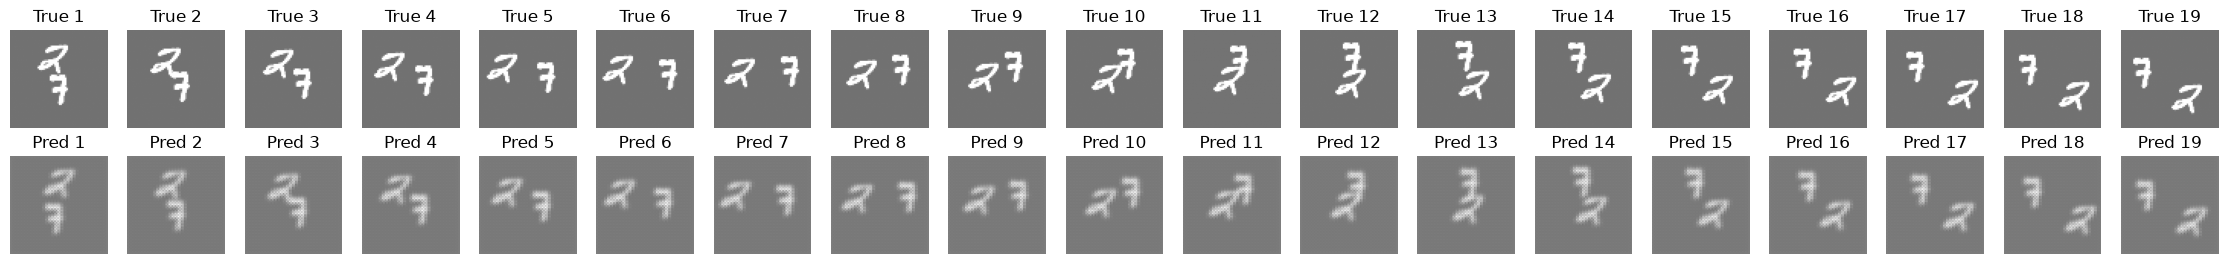

Identity check | ||delta||=0.042374  ||r_t-r_(t-1)||=2.599152  ratio=0.0163  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.033581  MSE(pred,true_(t-1))=0.013760  gap=+0.019820  COPY
[Epoch 001/020]  r_noise=0.0026  ss_p=0.021  Next-frame MSE: 0.033581  train_δ-ratio=0.0102  val_δ-ratio=0.0163
Identity check | ||delta||=0.121934  ||r_t-r_(t-1)||=3.176943  ratio=0.0384  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.034775  MSE(pred,true_(t-1))=0.010459  gap=+0.024316  COPY
[Epoch 002/020]  r_noise=0.0053  ss_p=0.042  Next-frame MSE: 0.034775  train_δ-ratio=0.0295  val_δ-ratio=0.0384
Identity check | ||delta||=0.239121  ||r_t-r_(t-1)||=3.545507  ratio=0.0674  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.035881  MSE(pred,true_(t-1))=0.008781  gap=+0.027100  COPY
[Epoch 003/020]  r_noise=0.0079  ss_p=0.063  Next-frame MSE: 0.035881  train_δ-ratio=0.0580  val_δ-ratio=0.0674
Identity check | ||delta||=0.379012  ||r_t-r_(t-1)||=3.790187  ratio=0.1000  delta_scale=1.0
Copy

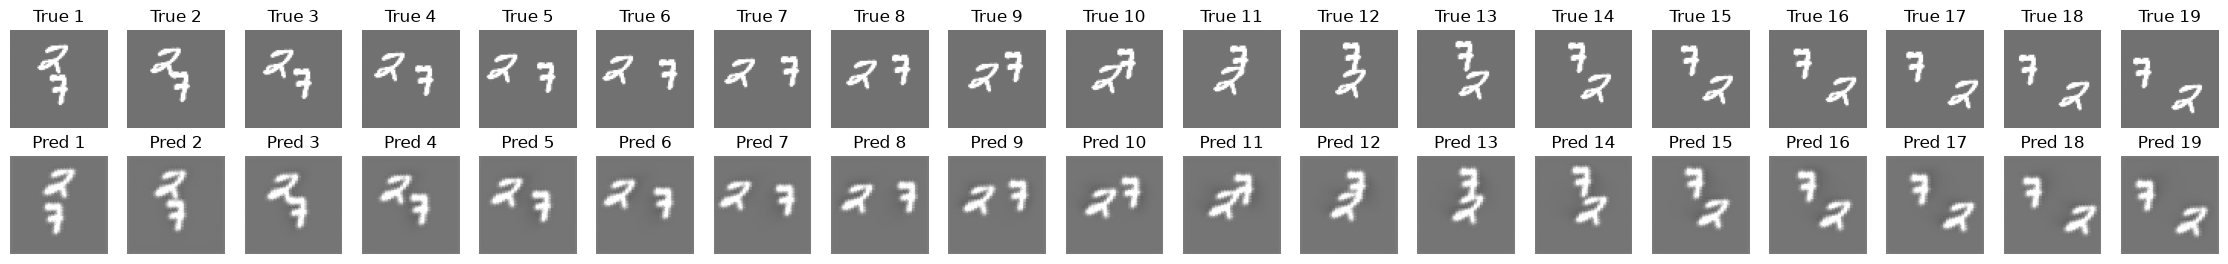

Identity check | ||delta||=0.636640  ||r_t-r_(t-1)||=4.084711  ratio=0.1559  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.037759  MSE(pred,true_(t-1))=0.006937  gap=+0.030822  COPY
[Epoch 006/020]  r_noise=0.0158  ss_p=0.126  Next-frame MSE: 0.037759  train_δ-ratio=0.1515  val_δ-ratio=0.1559
Identity check | ||delta||=0.730123  ||r_t-r_(t-1)||=4.177902  ratio=0.1748  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.038152  MSE(pred,true_(t-1))=0.006691  gap=+0.031460  COPY
[Epoch 007/020]  r_noise=0.0184  ss_p=0.147  Next-frame MSE: 0.038152  train_δ-ratio=0.1625  val_δ-ratio=0.1748
Identity check | ||delta||=0.804000  ||r_t-r_(t-1)||=4.248695  ratio=0.1892  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.038478  MSE(pred,true_(t-1))=0.006517  gap=+0.031961  COPY
[Epoch 008/020]  r_noise=0.0211  ss_p=0.168  Next-frame MSE: 0.038478  train_δ-ratio=0.1621  val_δ-ratio=0.1892
Identity check | ||delta||=0.858659  ||r_t-r_(t-1)||=4.306112  ratio=0.1994  delta_scale=1.0
Copy

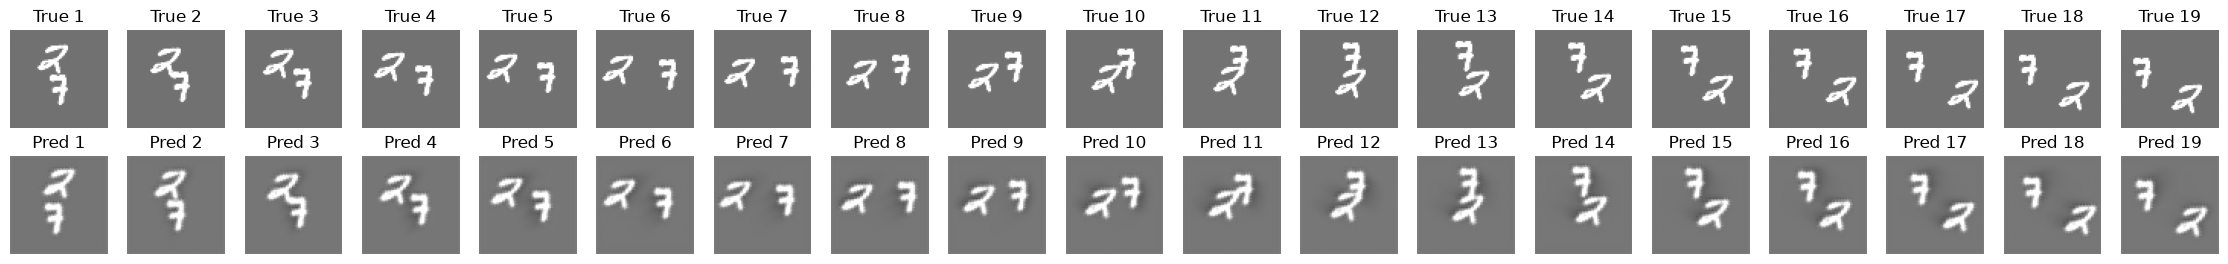

Identity check | ||delta||=0.925206  ||r_t-r_(t-1)||=4.403219  ratio=0.2101  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.039204  MSE(pred,true_(t-1))=0.006115  gap=+0.033089  COPY
[Epoch 011/020]  r_noise=0.0289  ss_p=0.232  Next-frame MSE: 0.039204  train_δ-ratio=0.1794  val_δ-ratio=0.2101
Identity check | ||delta||=0.953808  ||r_t-r_(t-1)||=4.438070  ratio=0.2149  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.039350  MSE(pred,true_(t-1))=0.006039  gap=+0.033311  COPY
[Epoch 012/020]  r_noise=0.0316  ss_p=0.253  Next-frame MSE: 0.039350  train_δ-ratio=0.1541  val_δ-ratio=0.2149
Identity check | ||delta||=0.972586  ||r_t-r_(t-1)||=4.471003  ratio=0.2175  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.039467  MSE(pred,true_(t-1))=0.005960  gap=+0.033507  COPY
[Epoch 013/020]  r_noise=0.0342  ss_p=0.274  Next-frame MSE: 0.039467  train_δ-ratio=0.1531  val_δ-ratio=0.2175
Identity check | ||delta||=0.989178  ||r_t-r_(t-1)||=4.501137  ratio=0.2198  delta_scale=1.0
Copy

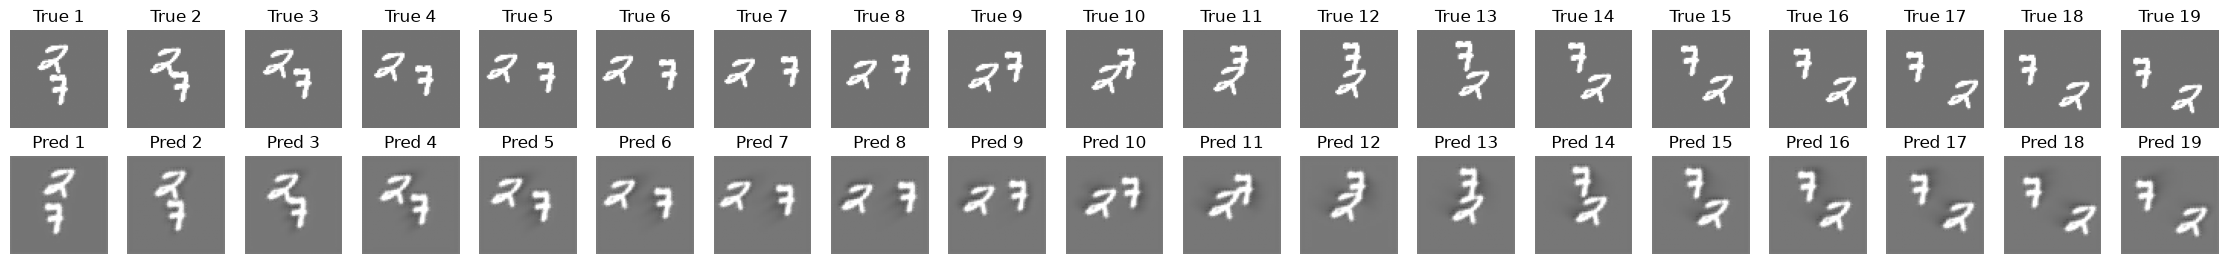

Identity check | ||delta||=1.026090  ||r_t-r_(t-1)||=4.550435  ratio=0.2255  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.039610  MSE(pred,true_(t-1))=0.005835  gap=+0.033774  COPY
[Epoch 016/020]  r_noise=0.0421  ss_p=0.337  Next-frame MSE: 0.039610  train_δ-ratio=0.1312  val_δ-ratio=0.2255
Identity check | ||delta||=1.041503  ||r_t-r_(t-1)||=4.573373  ratio=0.2277  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.039597  MSE(pred,true_(t-1))=0.005826  gap=+0.033770  COPY
[Epoch 017/020]  r_noise=0.0447  ss_p=0.358  Next-frame MSE: 0.039597  train_δ-ratio=0.1331  val_δ-ratio=0.2277
Identity check | ||delta||=1.061872  ||r_t-r_(t-1)||=4.593330  ratio=0.2312  delta_scale=1.0
Copy-last check | MSE(pred,true_t)=0.039561  MSE(pred,true_(t-1))=0.005827  gap=+0.033734  COPY
[Epoch 018/020]  r_noise=0.0474  ss_p=0.379  Next-frame MSE: 0.039561  train_δ-ratio=0.1180  val_δ-ratio=0.2312
Identity check | ||delta||=1.084717  ||r_t-r_(t-1)||=4.613355  ratio=0.2351  delta_scale=1.0
Copy

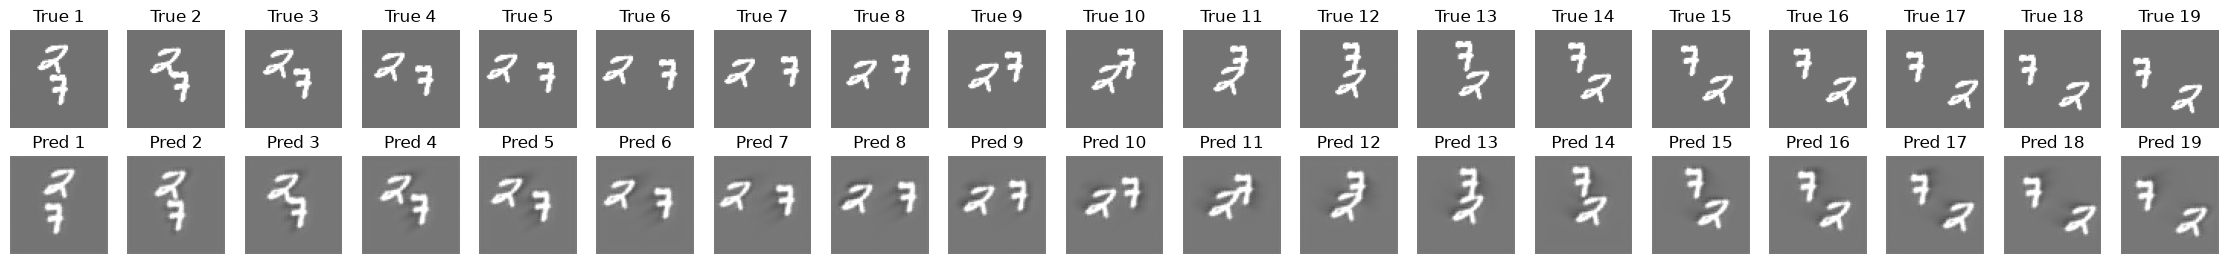


Post-train latent smoothness (learned dictionary, slowness in training only):

B. Latent smoothness [post-train encoder]

   t  cos(r_t,r_t-1)  ||dr||/||r_t||      ||dr||
   1          0.4817          1.0190      4.5053
   2          0.5336          0.9633      4.2811
   3          0.5384          0.9629      4.2614
   4          0.4717          1.0276      4.5507
   5          0.5387          0.9605      4.2536
   6          0.6609          0.8236      3.6473
   7          0.3599          1.1306      5.0149
   8          0.4232          1.0779      4.7468
   9          0.3582          1.1312      4.9968
  10          0.3767          1.1142      4.9424
  11          0.4464          1.0646      4.6158
  12          0.4069          1.0774      4.7754
  13          0.4309          1.0661      4.7317
  14          0.4049          1.0943      4.8272
  15          0.4356          1.0618      4.6902
  16          0.3815          1.1117      4.9152
  17          0.3633          1.1293      4.

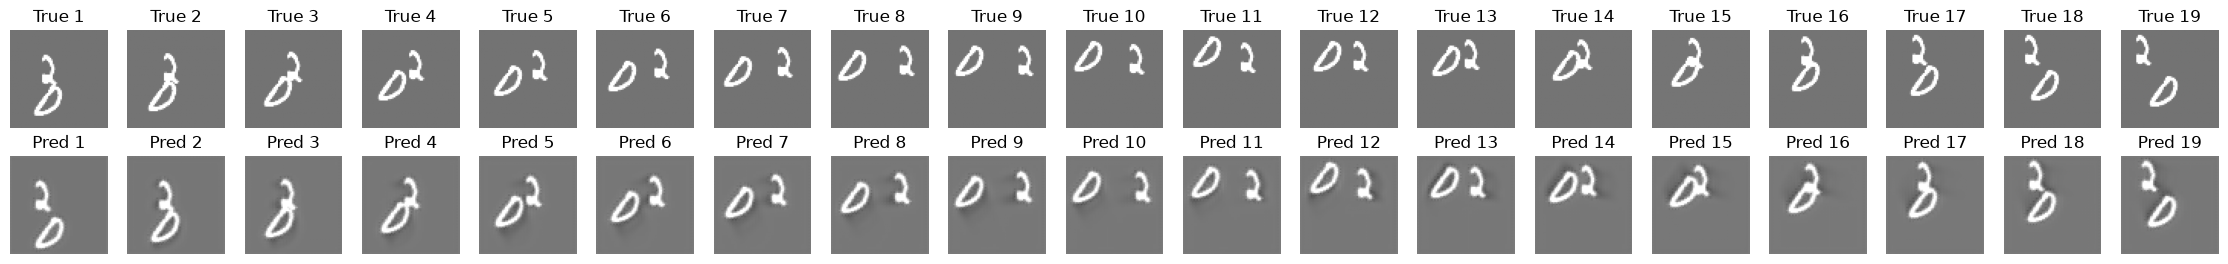

t=10 saturation | true: 0.0000 | substitute: 0.0000
Long-run  ->  MSE: 0.039182  |  Per-frame: ['0.0457', '0.0427', '0.0398', '0.0448', '0.0427', '0.0444', '0.0434', '0.0449', '0.0268', '0.0328', '0.0391', '0.0373', '0.0376', '0.0373', '0.0348', '0.0362', '0.0382', '0.0381', '0.0381']


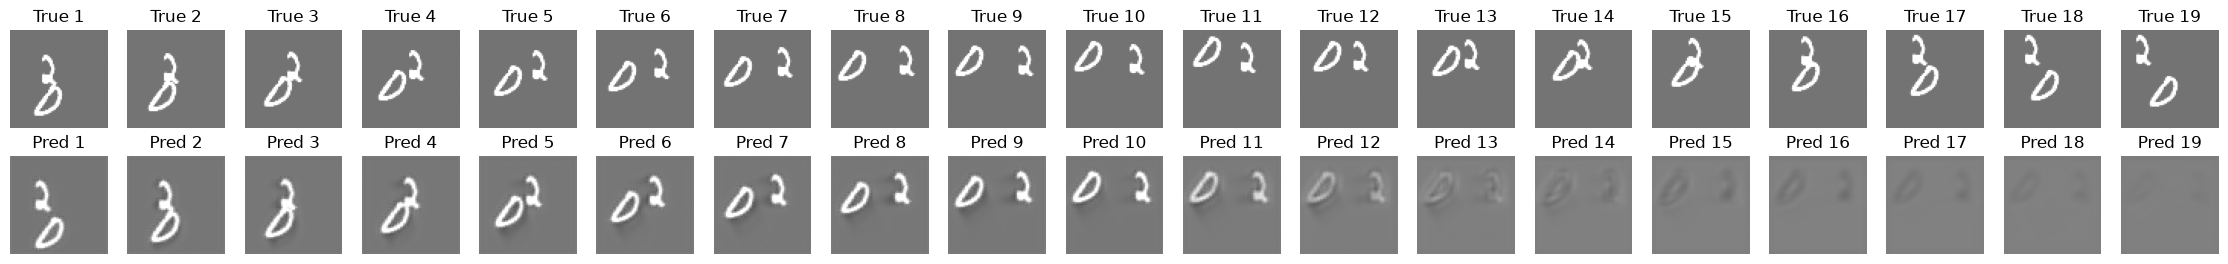

In [12]:
if __name__ == "__main__":
    main()
